# 🐱🐶 CNN Image Classification — Cat vs Dog

## Project Overview

This project focuses on building a Convolutional Neural Network (CNN)
for binary image classification.

The objective is to train a CNN model that can classify an input image
into one of two classes:

- 🐱 Cat
- 🐶 Dog

Instead of relying completely on high-level preprocessing pipelines,
the image preprocessing steps will be performed manually using Python,
PIL, NumPy, and scikit-learn.

The project covers the complete deep learning workflow:

1. Loading images
2. Understanding image dimensions
3. Converting images to RGB
4. Resizing images
5. Converting images into NumPy arrays
6. Normalizing pixel values
7. Encoding labels
8. Splitting the dataset
9. Data augmentation
10. Building a CNN
11. Training the CNN
12. Evaluating the model
13. Making predictions on unseen images

## 1. Import Required Libraries

We will use:

- `numpy` for numerical operations
- `pandas` for dataset information
- `matplotlib` for visualization
- `PIL` for reading and processing images
- `sklearn` for train/validation/test splitting and evaluation
- `tensorflow.keras` for building and training the CNN

In [71]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

## 2. Check TensorFlow Installation

Before starting the project, we verify that TensorFlow is installed
and can be imported successfully.

In [72]:
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)

TensorFlow: 2.21.0
NumPy: 2.4.6


## 3. Dataset Path

Our dataset is stored at:

F:\Anas\Dataset\PetImages

The dataset contains two class folders:

- Cat
- Dog

In [73]:
dataset_path = Path(
    r"F:\Anas\Dataset\PetImages"
)

print("Dataset path:")
print(dataset_path)

Dataset path:
F:\Anas\Dataset\PetImages


In [74]:
print(
    "Dataset exists:",
    dataset_path.exists()
)

Dataset exists: True


## 4. Explore Dataset Structure

Let's inspect the folders inside the dataset directory.

In [75]:
for item in dataset_path.iterdir():

    print(item)

F:\Anas\Dataset\PetImages\Cat
F:\Anas\Dataset\PetImages\Dog


## 5. Detect Classes

Each folder represents a class.

We will automatically detect the class folders rather than manually
hard-coding them.

In [76]:
classes = sorted([
    folder.name
    for folder in dataset_path.iterdir()
    if folder.is_dir()
])

print("Classes:", classes)
print("Number of classes:", len(classes))

Classes: ['Cat', 'Dog']
Number of classes: 2


## 6. Encode Class Labels

Machine learning models work with numerical labels.

We will map:

Cat → 0
Dog → 1

In [77]:
class_to_index = {
    class_name: index
    for index, class_name in enumerate(classes)
}

index_to_class = {
    index: class_name
    for class_name, index in class_to_index.items()
}

print("Class to index:")
print(class_to_index)

print("\nIndex to class:")
print(index_to_class)

Class to index:
{'Cat': 0, 'Dog': 1}

Index to class:
{0: 'Cat', 1: 'Dog'}


## 7. Count Images Per Class

Before training, we need to understand how many images
are available in each class.

This also helps us identify class imbalance.

In [78]:
image_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

class_counts = {}

for class_name in classes:

    class_path = dataset_path / class_name

    count = 0

    for image_path in class_path.iterdir():

        if image_path.suffix.lower() in image_extensions:

            count += 1

    class_counts[class_name] = count


print("Images per class:")

for class_name, count in class_counts.items():

    print(
        f"{class_name}: {count}"
    )

Images per class:
Cat: 12499
Dog: 12499


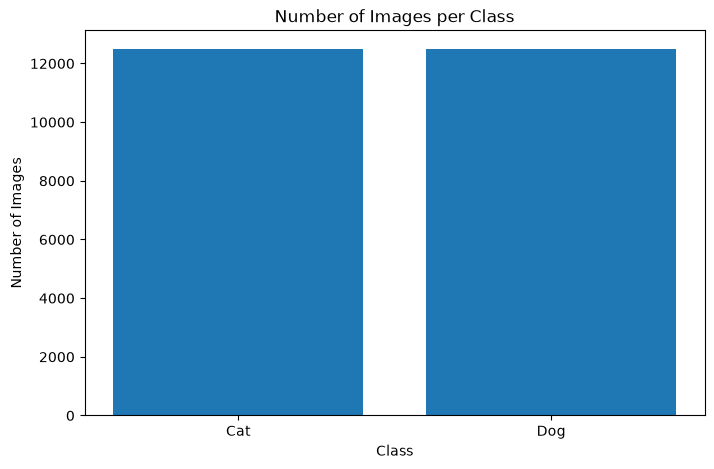

In [79]:
plt.figure(figsize=(8, 5))

plt.bar(
    class_counts.keys(),
    class_counts.values()
)

plt.title(
    "Number of Images per Class"
)

plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

## 8. Read a Sample Image

We will now manually open an image using PIL.

This helps us understand:

- Image dimensions
- Image format
- Color mode
- Pixel representation

In [80]:
sample_class = classes[0]

sample_folder = dataset_path / sample_class

sample_image_path = next(
    image_path
    for image_path in sample_folder.iterdir()
    if image_path.suffix.lower() in image_extensions
)

print(
    "Sample image:",
    sample_image_path
)

Sample image: F:\Anas\Dataset\PetImages\Cat\0.jpg


In [81]:
sample_image = Image.open(
    sample_image_path
)

print(
    "Image size:",
    sample_image.size
)

print(
    "Image mode:",
    sample_image.mode
)

Image size: (500, 375)
Image mode: RGB


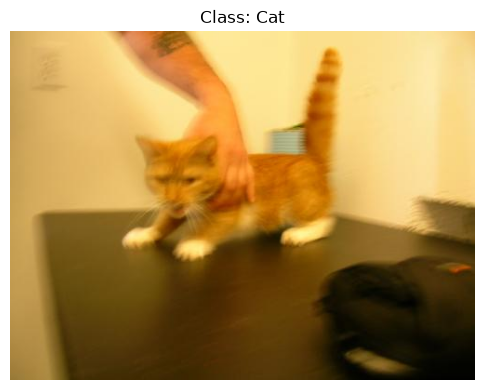

In [82]:
plt.figure(figsize=(6, 6))

plt.imshow(sample_image)

plt.title(
    f"Class: {sample_class}"
)

plt.axis("off")

plt.show()

## 9. Convert Images to RGB

Images can have different color modes:

- RGB
- RGBA
- Grayscale
- CMYK

To make our dataset consistent, every image will be converted
to RGB.

RGB contains three channels:

- Red
- Green
- Blue

In [83]:
sample_image = sample_image.convert(
    "RGB"
)

print(
    "Image mode:",
    sample_image.mode
)

Image mode: RGB


## 10. Resize Images

Images in the dataset may have different dimensions.

A CNN requires a consistent input size.

We will resize every image to:

128 × 128 × 3

Where:

128 → height
128 → width
3 → RGB channels

In [84]:
IMAGE_SIZE = (128, 128)

sample_resized = sample_image.resize(
    IMAGE_SIZE
)

print(
    "Resized image:",
    sample_resized.size
)

Resized image: (128, 128)


## 11. Convert Image to NumPy Array

A PIL image must be converted into a numerical array
before it can be given to a neural network.

The resulting shape will be:

(128, 128, 3)

In [85]:
sample_array = np.array(
    sample_resized
)

print(
    "Shape:",
    sample_array.shape
)

print(
    "Data type:",
    sample_array.dtype
)

print(
    "Minimum pixel:",
    sample_array.min()
)

print(
    "Maximum pixel:",
    sample_array.max()
)

Shape: (128, 128, 3)
Data type: uint8
Minimum pixel: 0
Maximum pixel: 255


## 12. Normalize Pixel Values

Original image pixels normally have values between:

0 and 255

We normalize them to:

0 and 1

Formula:

normalized_pixel = pixel / 255

For example:

0 → 0.0
128 → 0.502
255 → 1.0

Normalization helps neural networks train more effectively.

In [86]:
sample_normalized = (
    sample_array.astype(np.float32) / 255.0
)

print(
    "Minimum:",
    sample_normalized.min()
)

print(
    "Maximum:",
    sample_normalized.max()
)

print(
    "Data type:",
    sample_normalized.dtype
)

Minimum: 0.0
Maximum: 1.0
Data type: float32


## 13. Build the Complete Dataset

For every image:

1. Read image
2. Convert to RGB
3. Resize to 128 × 128
4. Convert to NumPy array
5. Convert to float32
6. Normalize pixels
7. Store image
8. Store label

Invalid or corrupted images will be skipped instead of stopping
the entire preprocessing process.

In [87]:
X = []
y = []

valid_images = 0
skipped_images = 0

for class_name in classes:

    class_path = dataset_path / class_name

    label = class_to_index[class_name]

    print(
        f"Processing {class_name}..."
    )

    for image_path in class_path.iterdir():

        if image_path.suffix.lower() not in image_extensions:
            continue

        try:

            # Read image
            image = Image.open(
                image_path
            )

            # Convert to RGB
            image = image.convert(
                "RGB"
            )

            # Resize
            image = image.resize(
                IMAGE_SIZE
            )

            # Convert to NumPy
            image_array = np.array(
                image,
                dtype=np.float32
            )

            # Normalize
            image_array /= 255.0

            # Store
            X.append(
                image_array
            )

            y.append(
                label
            )

            valid_images += 1

        except Exception as e:

            skipped_images += 1

            print(
                f"Skipped: {image_path}"
            )

print("\nPreprocessing complete.")

print(
    "Valid images:",
    valid_images
)

print(
    "Skipped images:",
    skipped_images
)

Processing Cat...
Processing Dog...


f:\Anas\DATA_SCIENCE_POTPOLIO\.venv\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))



Preprocessing complete.
Valid images: 24998
Skipped images: 0


In [88]:
X = np.array(
    X,
    dtype=np.float32
)

y = np.array(
    y,
    dtype=np.int32
)

print(
    "X shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)

X shape: (24998, 128, 128, 3)
y shape: (24998,)


## 14. Verify the Preprocessed Dataset

We should verify:

- Number of images
- Image dimensions
- Number of channels
- Pixel range
- Labels

In [89]:
print("Number of images:", len(X))

print(
    "Image shape:",
    X.shape[1:]
)

print(
    "Pixel minimum:",
    X.min()
)

print(
    "Pixel maximum:",
    X.max()
)

print(
    "Labels:",
    np.unique(y)
)

Number of images: 24998
Image shape: (128, 128, 3)
Pixel minimum: 0.0
Pixel maximum: 1.0
Labels: [0 1]


In [90]:
unique_labels, label_counts = np.unique(
    y,
    return_counts=True
)

for label, count in zip(
    unique_labels,
    label_counts
):

    print(
        f"{index_to_class[label]}: {count}"
    )

Cat: 12499
Dog: 12499


## 15. Visualize Preprocessed Images

Let's verify that resizing and normalization did not damage
the images.

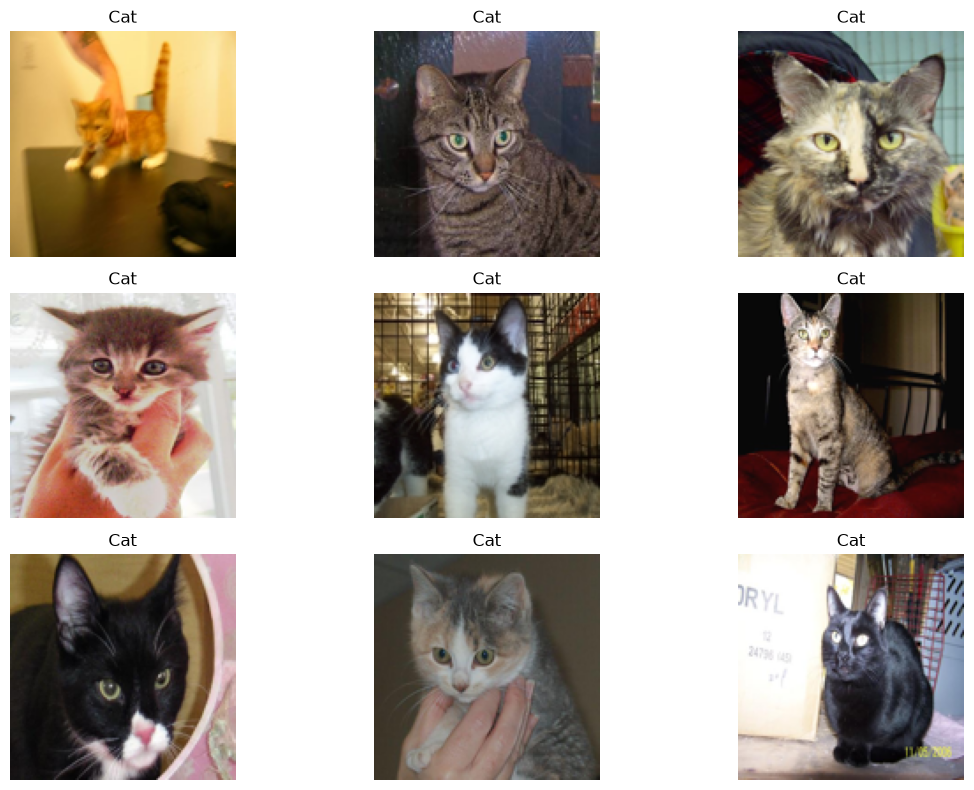

In [91]:
plt.figure(figsize=(12, 8))

for i in range(9):

    plt.subplot(
        3,
        3,
        i + 1
    )

    plt.imshow(
        X[i]
    )

    plt.title(
        index_to_class[y[i]]
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

## 16. Train / Validation / Test Split

We divide the dataset into three parts.

### Training Set — 70%

Used to learn the model parameters.

### Validation Set — 15%

Used to monitor performance during training.

### Test Set — 15%

Used only for final evaluation.

We use stratified splitting so that both classes maintain
approximately the same proportion in each dataset.

In [92]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [93]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [94]:
print(
    "Training:",
    X_train.shape,
    y_train.shape
)

print(
    "Validation:",
    X_val.shape,
    y_val.shape
)

print(
    "Testing:",
    X_test.shape,
    y_test.shape
)

Training: (17498, 128, 128, 3) (17498,)
Validation: (3750, 128, 128, 3) (3750,)
Testing: (3750, 128, 128, 3) (3750,)


In [95]:
def show_distribution(
    labels,
    dataset_name
):

    unique, counts = np.unique(
        labels,
        return_counts=True
    )

    print(
        f"\n{dataset_name}"
    )

    for label, count in zip(
        unique,
        counts
    ):

        print(
            f"{index_to_class[label]}: {count}"
        )


show_distribution(
    y_train,
    "Training"
)

show_distribution(
    y_val,
    "Validation"
)

show_distribution(
    y_test,
    "Testing"
)


Training
Cat: 8749
Dog: 8749

Validation
Cat: 1875
Dog: 1875

Testing
Cat: 1875
Dog: 1875


## 17. Data Augmentation

Data augmentation generates slightly modified versions of
training images.

We will use:

- Random horizontal flip
- Random rotation
- Random zoom
- Random contrast

These transformations help reduce overfitting.

Important:

Data augmentation is used during training only.

Validation and test images remain unchanged.

In [96]:
data_augmentation = keras.Sequential([

    layers.RandomFlip(
        "horizontal"
    ),

    layers.RandomRotation(
        0.1
    ),

    layers.RandomZoom(
        0.1
    ),

    layers.RandomContrast(
        0.1
    )

])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.016029418..1.0194387].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0613298].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.006968707..1.0092157].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.00293836..1.0340607].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0397213].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0024631321..1.010773].


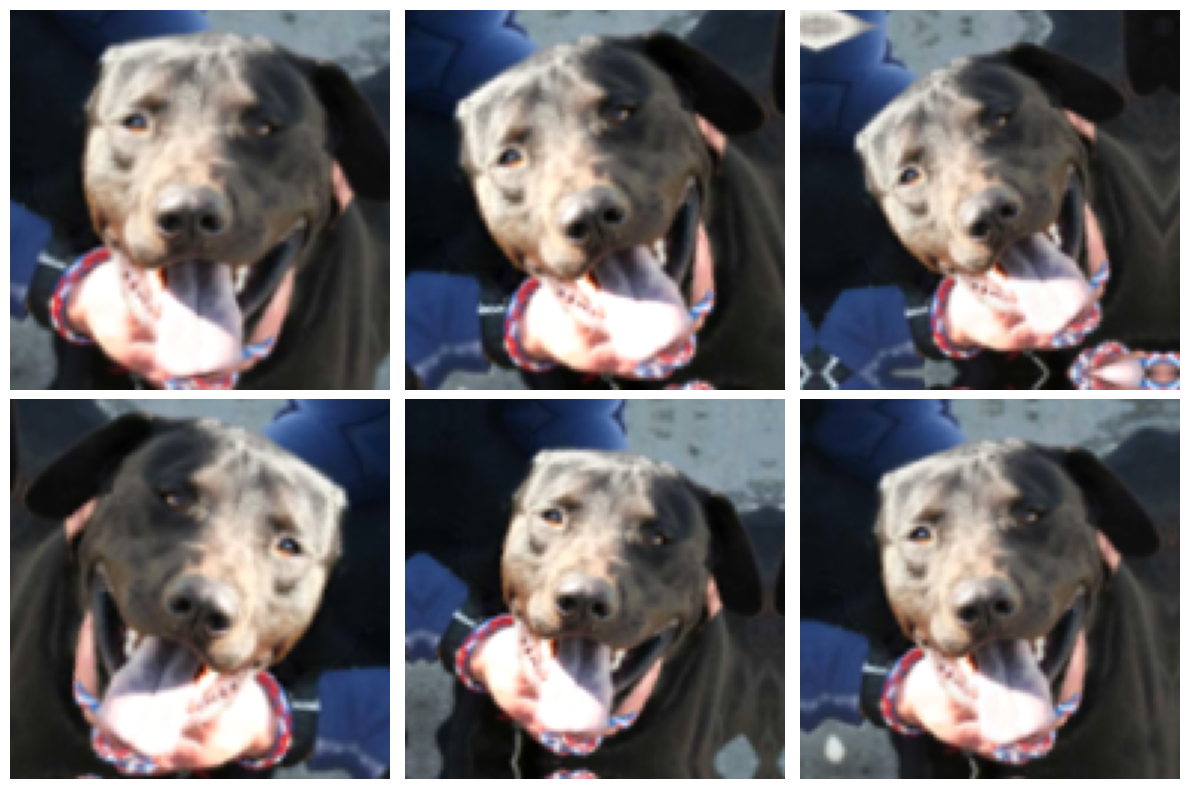

In [97]:
sample = X_train[0]

plt.figure(figsize=(12, 8))

for i in range(6):

    augmented = data_augmentation(
        np.expand_dims(
            sample,
            axis=0
        ),
        training=True
    )

    plt.subplot(
        2,
        3,
        i + 1
    )

    plt.imshow(
        augmented[0].numpy()
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

# 18. Build the Convolutional Neural Network


In [98]:
model = keras.Sequential([

    # Input
    layers.Input(
        shape=(128, 128, 3)
    ),

    # Data augmentation
    data_augmentation,

    # Convolution Block 1
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # Convolution Block 2
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # Convolution Block 3
    layers.Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # Flatten
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(
        128,
        activation="relu"
    ),

    # Dropout
    layers.Dropout(
        0.5
    ),

    # Output
    layers.Dense(
        1,
        activation="sigmoid"
    )
])

## 19. CNN Architecture Summary

In [99]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,809 (16.36 MB)

 Trainable params: 4,287,809 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

## 20. Compile the CNN

We use:

### Optimizer
Adam

The optimizer updates the model weights using the gradients
calculated during backpropagation.

### Loss Function
Binary Crossentropy

Because we have two classes.

### Metric
Accuracy

Used to monitor classification performance.

In [100]:
model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="binary_crossentropy",

    metrics=[
        "accuracy"
    ]
)

# 21. Train the CNN

During training:

1. The image enters the CNN.
2. Convolution filters extract features.
3. The network produces a prediction.
4. Binary crossentropy calculates the loss.
5. Backpropagation calculates gradients.
6. Adam updates the weights.
7. The process repeats for multiple batches.
8. Validation data is used to monitor generalization.

In [101]:
history = model.fit(

    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=20,

    batch_size=32,

    verbose=1
)

Epoch 1/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 52s 93ms/step - accuracy: 0.6154 - loss: 0.6578 - val_accuracy: 0.6952 - val_loss: 0.5819
Epoch 2/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 51s 94ms/step - accuracy: 0.6916 - loss: 0.5824 - val_accuracy: 0.7344 - val_loss: 0.5317
Epoch 3/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 51s 94ms/step - accuracy: 0.7312 - loss: 0.5410 - val_accuracy: 0.7560 - val_loss: 0.5131
Epoch 4/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 51s 93ms/step - accuracy: 0.7502 - loss: 0.5102 - val_accuracy: 0.7728 - val_loss: 0.4758
Epoch 5/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 52s 96ms/step - accuracy: 0.7715 - loss: 0.4791 - val_accuracy: 0.7923 - val_loss: 0.4467
Epoch 6/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 52s 96ms/step - accuracy: 0.7841 - loss: 0.4592 - val_accuracy: 0.8093 - val_loss: 0.4267
Epoch 7/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 51s 93ms/step - accuracy: 0.7989 - loss: 0.4351 - val_accuracy: 0.8203 - val_loss: 0.4087
Epoch 8/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 51s 93ms/step - accuracy: 0.8084 - loss: 0.4230 - 

## 22. Training vs Validation Accuracy

The accuracy graph helps us understand how the model
learns over time.

If training accuracy continues increasing while validation
accuracy stops improving or decreases, the model may be overfitting.

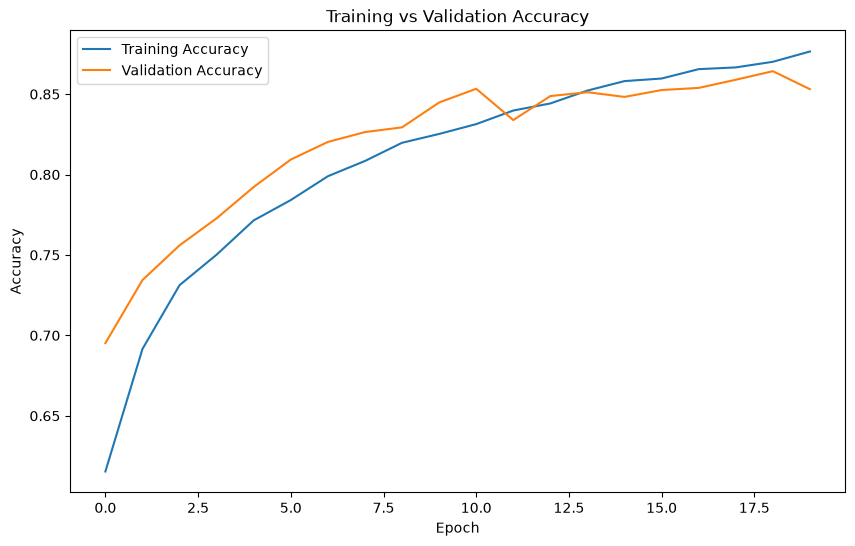

In [102]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "Training vs Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

## 23. Training vs Validation Loss

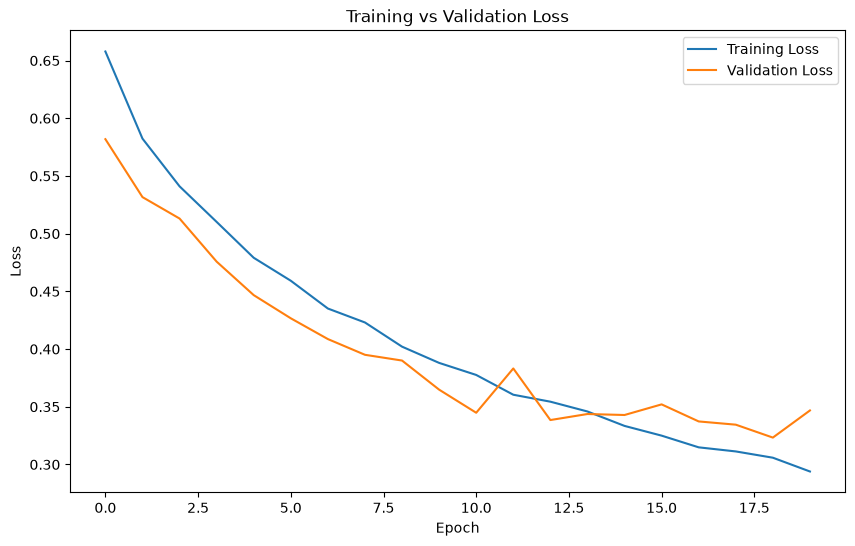

In [103]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "Training vs Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

# 24. Evaluate the CNN on Test Data

The test dataset contains images that were not used
to train the model.

This gives us the final estimate of model performance.

In [104]:
test_loss, test_accuracy = model.evaluate(

    X_test,
    y_test,

    verbose=1
)

print(
    f"Test Loss: {test_loss:.4f}"
)

print(
    f"Test Accuracy: {test_accuracy:.4f}"
)

118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8645 - loss: 0.3335
Test Loss: 0.3335
Test Accuracy: 0.8645


## 25. Generate Predictions

The sigmoid output produces a probability between 0 and 1.

We use:

Probability < 0.5 → Cat
Probability >= 0.5 → Dog

In [105]:
y_probability = model.predict(
    X_test,
    verbose=1
)

y_probability = y_probability.ravel()

y_pred = (
    y_probability >= 0.5
).astype(int)

118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step


In [106]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Accuracy: {accuracy:.4f}"
)

Accuracy: 0.8645


# 26. Confusion Matrix

The confusion matrix shows:

- True Cat predicted as Cat
- True Cat predicted as Dog
- True Dog predicted as Cat
- True Dog predicted as Dog

In [107]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[1479  396]
 [ 112 1763]]


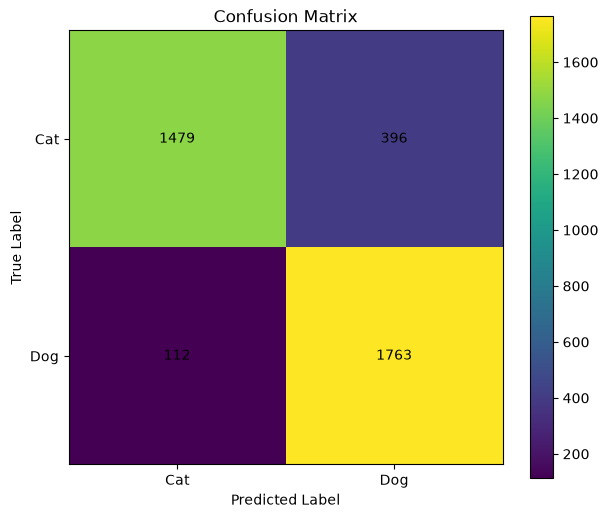

In [108]:
plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.xticks(
    [0, 1],
    classes
)

plt.yticks(
    [0, 1],
    classes
)

for i in range(
    len(classes)
):

    for j in range(
        len(classes)
    ):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.show()

# 27. Classification Report

The classification report provides:

- Precision
- Recall
- F1-score
- Support

These metrics provide more information than accuracy alone.

In [109]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=classes
    )
)

              precision    recall  f1-score   support

         Cat       0.93      0.79      0.85      1875
         Dog       0.82      0.94      0.87      1875

    accuracy                           0.86      3750
   macro avg       0.87      0.86      0.86      3750
weighted avg       0.87      0.86      0.86      3750



## 28. Visualize Model Predictions

Let's display test images together with their predicted
and actual classes.

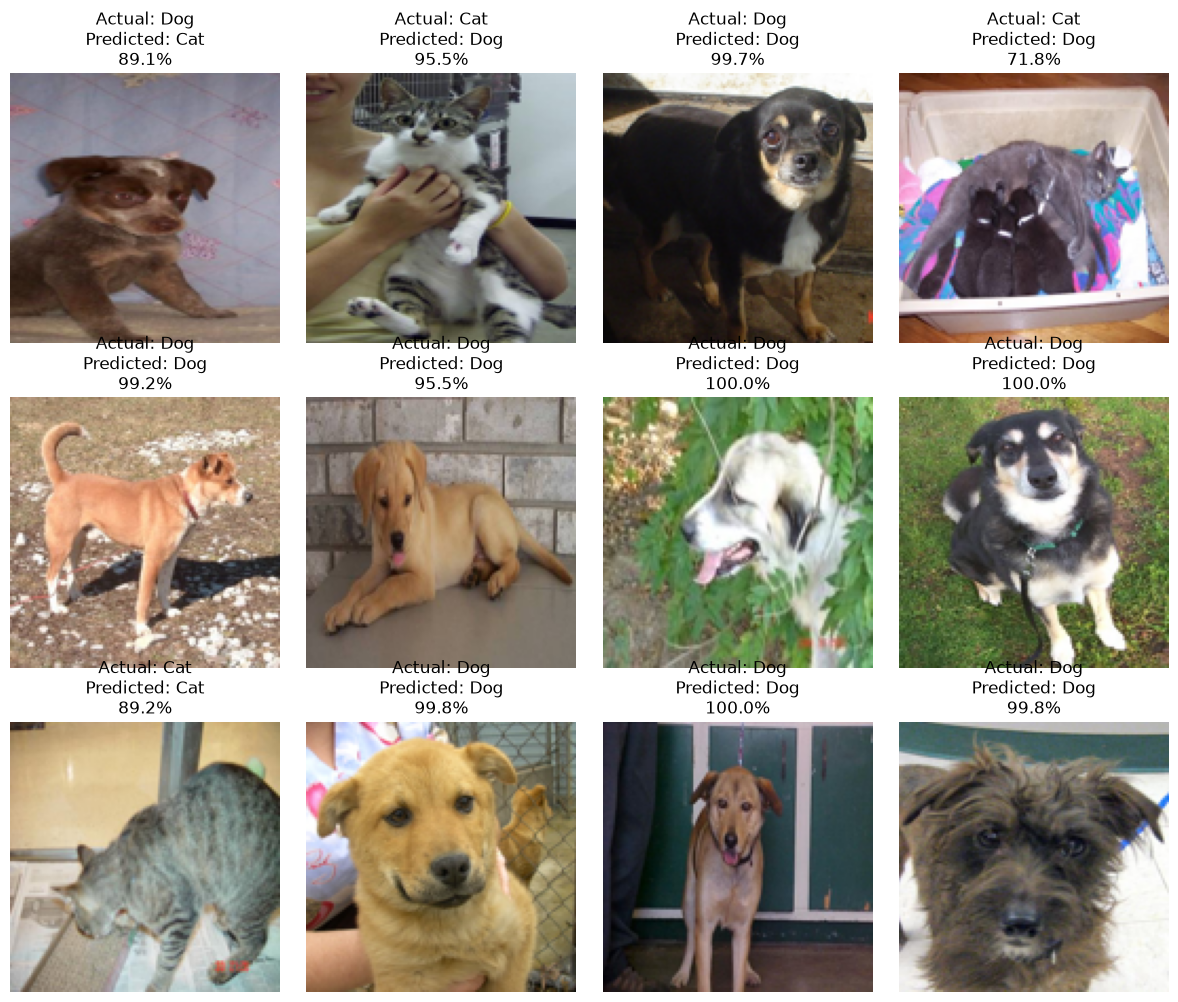

In [110]:
plt.figure(figsize=(12, 10))

for i in range(12):

    plt.subplot(
        3,
        4,
        i + 1
    )

    plt.imshow(
        X_test[i]
    )

    actual = index_to_class[
        y_test[i]
    ]

    predicted = index_to_class[
        y_pred[i]
    ]

    confidence = (
        y_probability[i]
        if y_pred[i] == 1
        else 1 - y_probability[i]
    )

    plt.title(
        f"Actual: {actual}\n"
        f"Predicted: {predicted}\n"
        f"{confidence * 100:.1f}%"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

## 29. Analyze Incorrect Predictions

Incorrect predictions can help us understand where the CNN
has difficulty.

In [111]:
incorrect_indices = np.where(
    y_test != y_pred
)[0]

print(
    "Incorrect predictions:",
    len(incorrect_indices)
)

Incorrect predictions: 508


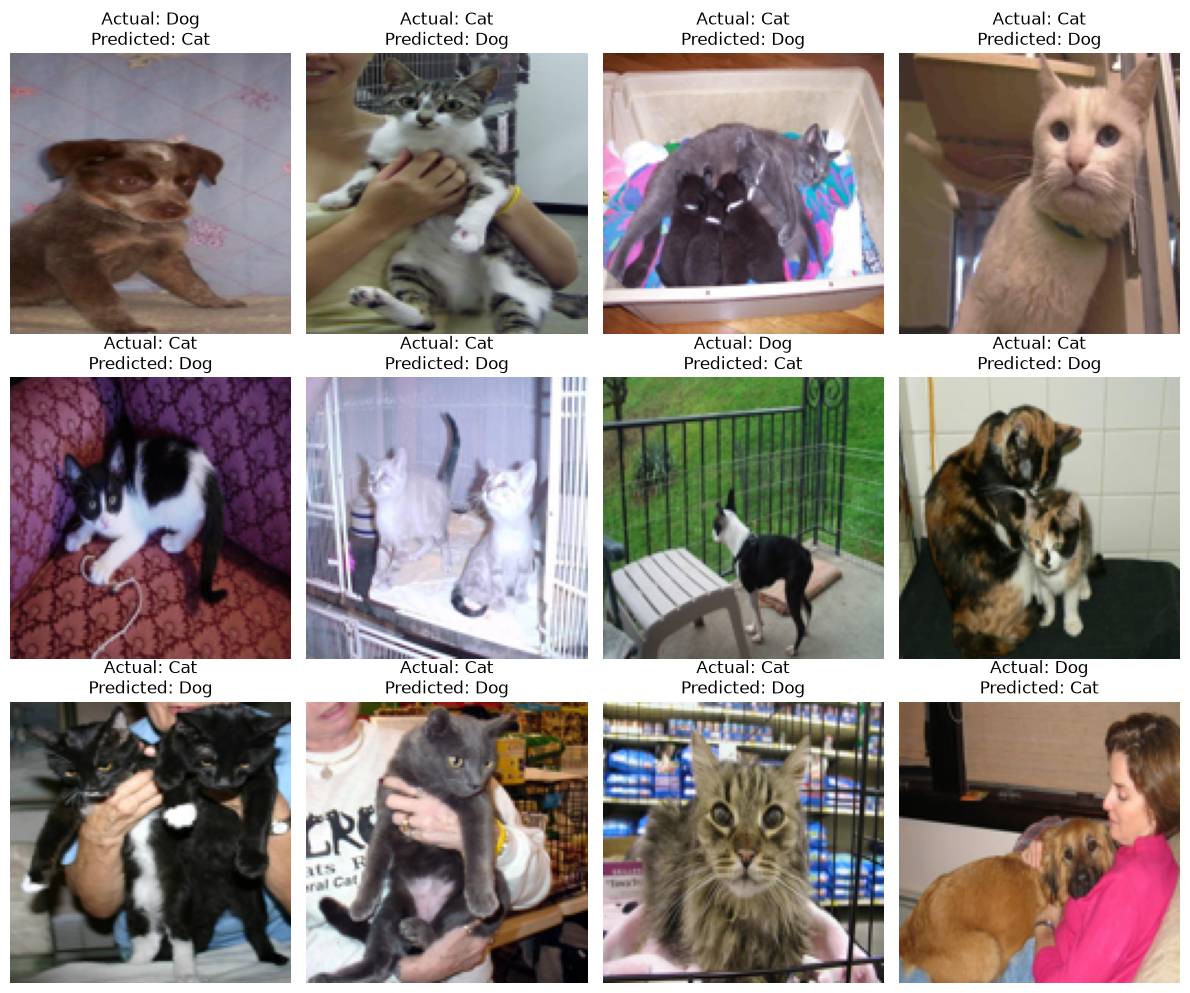

In [112]:
plt.figure(figsize=(12, 10))

num_images = min(
    12,
    len(incorrect_indices)
)

for i in range(num_images):

    index = incorrect_indices[i]

    plt.subplot(
        3,
        4,
        i + 1
    )

    plt.imshow(
        X_test[index]
    )

    actual = index_to_class[
        y_test[index]
    ]

    predicted = index_to_class[
        y_pred[index]
    ]

    plt.title(
        f"Actual: {actual}\n"
        f"Predicted: {predicted}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

# 30. Create Image Preprocessing Function

The model expects every new image to go through the same
preprocessing steps used during training.

Therefore:

New Image
↓
RGB
↓
128 × 128
↓
NumPy
↓
Float32
↓
Normalize
↓
Add Batch Dimension
↓
CNN

In [113]:
def preprocess_image(image_path):

    image = Image.open(
        image_path
    )

    image = image.convert(
        "RGB"
    )

    image = image.resize(
        IMAGE_SIZE
    )

    image_array = np.array(
        image,
        dtype=np.float32
    )

    image_array /= 255.0

    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    return image, image_array

In [114]:
def predict_image(image_path):

    image, image_array = preprocess_image(
        image_path
    )

    probability = model.predict(
        image_array,
        verbose=0
    )[0][0]

    if probability >= 0.5:

        predicted_class = "Dog"
        confidence = probability

    else:

        predicted_class = "Cat"
        confidence = 1 - probability

    return (
        image,
        predicted_class,
        confidence
    )

# Save  the Trained CNN

In [117]:
model.save(
    "cat_dog_cnn.keras"
)

print(
    "Model saved successfully!"
)

Model saved successfully!
